# REGRESSION:

### Regression is used to predict continuous numerical values.

### Examples

* Salary Prediction
* Temperature Prediction
* House Price Prediction

## INPUT AND OUTPUT

* **Input (X)** → Independent Variable
* **Output (Y)** → Dependent Variable

### Example: Salary Prediction

**Input (X)** → Years of Experience

**Output (Y)** → Salary

If experience increases and salary also increases → **Positive Relationship (+ve)**

If experience increases and salary decreases → **Negative Relationship (-ve)**

---

# LINEAR REGRESSION

**Linear Regression is a regression algorithm used to predict continuous numerical values by finding a linear relationship between input and output.**

## 2 TYPES:

### 1. Simple Linear Regression

**1 Input → 1 Output**

Example:
**Years of Experience → Salary**

### 2. Multiple Linear Regression

**Multiple Inputs → 1 Output**

Example:
**Experience + Age + Education → Salary**

---

# EXAMPLE

| Years of Experience | Salary |
| ------------------: | -----: |
|                   1 |    20K |
|                 1.5 |    18K |
|                   2 |    35K |
|                   3 |    38K |

---

# REGRESSION LINE / BEST FIT LINE

The **best fit line** is the straight line that represents the relationship between the input and output values as closely as possible.

### Equation

**Y = MX + C**

* **Y** → Predicted Output
* **X** → Input
* **M** → Slope / Coefficient of Regression
* **C** → Constant / Y-intercept

### Y-INTERCEPT

**Y-intercept is the value of Y when X = 0.**

### SLOPE

**Slope tells how much Y changes when X increases by 1 unit.**


In [94]:
import pandas as pd
df=pd.read_csv("/content/salary_data (2).csv")
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [95]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [96]:
df.tail()

,YearsExperience,Salary
25,9.0,105582
26,9.5,116969
27,9.6,112635
28,10.3,122391
29,10.5,121872


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [98]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [101]:
x=df.iloc[:,:-1]
x.ndim

2

In [102]:
y=df.Salary
y.ndim

1

In [103]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=41)

In [104]:
# Linear Model
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [105]:
# training
lr.fit(xtrain,ytrain)

LinearRegression()

In [106]:
# prediction
ypred=lr.predict(xtest)
ypred

array([ 64150.92490713, 125415.11884062,  63208.39884661,  90541.65460156,
       115989.85823547,  53783.13824146, 108449.64975135,  68863.55520971,
        56610.71642301])

In [107]:
ytest.values

array([ 55794, 121872,  63218,  91738, 116969,  56642, 109431,  61111,
        54445])

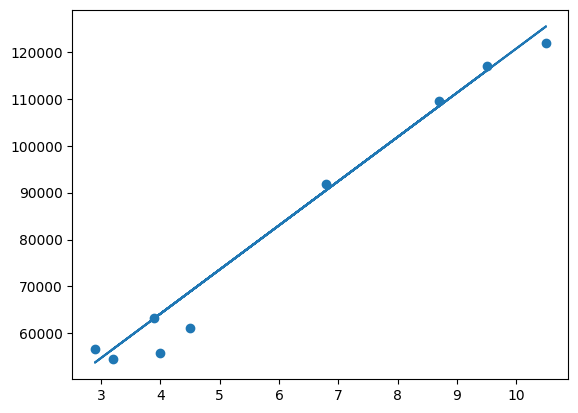

In [108]:
# regresssion plot
import matplotlib.pyplot as plt

# actual DATA
plt.scatter(xtest,ytest,label="Actual")

# predicted O/P
plt.plot(xtest,ypred,label="Prediction")

plt.legend
plt.show()

In [109]:
# error/residual = difference btw acutal o/p and predicted o/p
                 # actual o/p - predicted o/p
                 # y - y'
print("coeff of reg",lr.coef_)

coeff of reg [9425.26060515]


In [110]:
print("y_intercept",lr.intercept_)

y_intercept 26449.882486518865


In [111]:
y_new=9425.26060515 *1.1 + 26449.882486518865
y_new
# (1.1 is taken from the first of the dataset)

36817.669152183866

# PERFORMANCE EVALUATION IN REGRESSION

These methods are used to **check how accurate a regression model is**.

### ERROR

**Error = Actual Value - Predicted Value**

        **= Y - Ŷ**

* **Y** → Actual value
* **Ŷ** → Predicted value

## 1. MEAN SQUARED ERROR (MSE)

**MSE = Average of squared errors**

**MSE = Σ(Y - Ŷ)² / N**

* Lower MSE = Better model

## 2. ROOT MEAN SQUARED ERROR (RMSE)

**RMSE = √MSE**

**RMSE = √[Σ(Y - Ŷ)² / N]**

* Lower RMSE = Better model
* RMSE is in the same unit as the output

## 3. MEAN ABSOLUTE ERROR (MAE)

**MAE = Average of absolute errors**

**MAE = Σ|Y - Ŷ| / N**

* Lower MAE = Better model

## 4. MEAN ABSOLUTE PERCENTAGE ERROR (MAPE)

**MAPE = Average percentage error**

**MAPE = [Σ|(Y - Ŷ) / Y| / N] × 100**

* Lower MAPE = Better model

## 5. R² SCORE / R-SQUARED

**R² = Coefficient of Determination**

* Shows how much of the variation in the output is explained by the model.
* **R² ranges from 0 to 1**
* Higher R² = Better fit

In [112]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score


In [114]:
mean_squared_error(ytest,ypred)

17634501.87568305

In [115]:
mean_absolute_error(ytest,ypred)

3093.7350782238145

In [117]:
r2_score(ytest,ypred)

0.9757061954716729